In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/IMDB Dataset.csv")  # change filename if needed

# Convert labels
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'],
    test_size=0.2, random_state=42
)

In [4]:
max_words = 10000
max_len = 200

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_len)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_len)

In [5]:
model = models.Sequential([
    layers.Embedding(max_words, 128),

    # 🔥 Better than Flatten
    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),   # 🔥 prevents overfitting

    layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.8001 - loss: 0.4220 - val_accuracy: 0.8796 - val_loss: 0.2873
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.8957 - loss: 0.2641 - val_accuracy: 0.8719 - val_loss: 0.2985
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9164 - loss: 0.2221 - val_accuracy: 0.8817 - val_loss: 0.2890


In [9]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.2824
Test Accuracy: 0.8819000124931335


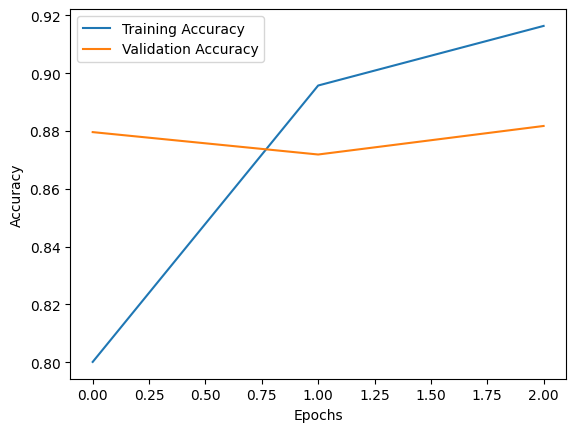

In [10]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [12]:
review = ["This movie was boring"]

# Tokenize
seq = tokenizer.texts_to_sequences(review)

# Pad
seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_len)

# Predict
prediction = model.predict(seq)

print("Sentiment:", "Positive" if prediction[0][0] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Sentiment: Negative
